In [1]:
from pandas import read_csv
import matplotlib.pyplot as plt
import numpy as np
from sklearn import preprocessing
from sklearn.model_selection import train_test_split
from sklearn import svm
from sklearn import metrics

In [2]:
df = read_csv("../../datasets/Customer_Churn.csv")

x = df[['Call  Failure', 'Complains', 'Subscription  Length', 'Charge  Amount',
       'Seconds of Use', 'Frequency of use', 'Frequency of SMS',
       'Distinct Called Numbers', 'Age Group', 'Tariff Plan', 'Status', 'Age',
       'Customer Value']].values

y = df['Churn'].values

x = preprocessing.StandardScaler().fit(x).transform(x.astype(float))

x_train, x_test, y_train, y_test = train_test = train_test_split(x, y, test_size=0.2, random_state=3)
print("train data: ", x_train.shape, y_train.shape)
print("test data: ", x_test.shape, y_test.shape)

train data:  (2520, 13) (2520,)
test data:  (630, 13) (630,)


In [19]:
kernels = ['poly', 'rbf', 'sigmoid', 'linear']
for kernel in kernels:
    clf = svm.SVC(kernel=kernel, C=100)
    clf.fit(x_train, y_train)

    yhat = clf.predict(x_test)
    fs = metrics.f1_score(y_test, yhat)
    print(kernel, fs)

# C=100, kernel='rbf'

poly 0.8275862068965517
rbf 0.8926553672316384
sigmoid 0.49214659685863876


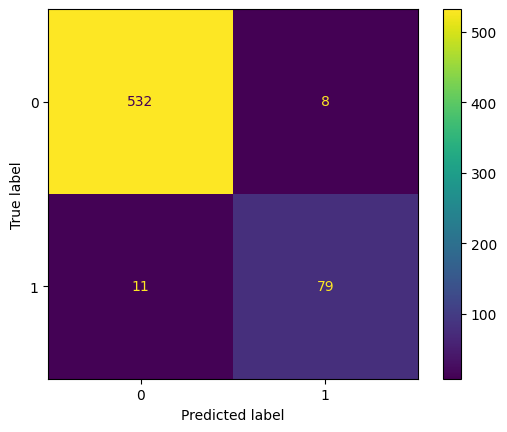

In [20]:
clf = svm.SVC(kernel='rbf', C=100).fit(x_train, y_train)
yhat = clf.predict(x_test)
cm = metrics.confusion_matrix(y_test, yhat)

disp = metrics.ConfusionMatrixDisplay(cm)
disp.plot()
# As you see desicion tree shows better results.